# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
target_case = 'EF_nmhcp'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
import seaborn as sns
from Tools.DatasetTools.MLConveniences import filter_features
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate
import joblib
import pickle

In [2]:
DS = Dataset(dataset=dataset)

In [3]:
BS = DS.BS # pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')

In [4]:
BS = BS.loc[~BS.index.str.contains('delta')]

In [5]:
TRAIN_RBS = BS.query('Phase == "R"')

In [6]:
TRAIN_RBS.shape

(9, 23)

In [7]:
TRAIN_RBS.index

Index(['Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM', 'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv53.R.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM',
       'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM'],
      dtype='object')

In [8]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=12)

In [9]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [10]:
binaryr = permutate('R', 2, 11)

In [11]:
atoms_objects_file = os.path.join(dataset,'Atomsobjects/R_structures.pkl')

In [12]:
os.path.exists(atoms_objects_file)

True

In [13]:
if os.path.exists(atoms_objects_file):
    AtomsObjects = pd.read_pickle(atoms_objects_file)
else:
    AtomsObjects = make_all_atoms_objects(binaryr)
    AtomsObjects = AtomsObjects.to_frame()
    AtomsObjects.columns = ['atoms']
    AtomsObjects.to_pickle(atoms_object_file)

In [14]:
RBS = AtomsObjects

In [15]:
RBS['num_atoms'] = RBS.atoms.map(len)

In [16]:
RBS[['Fe', 'Mo']] = pd.DataFrame.from_dict(
    RBS.atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
    orient = 'index'
).fillna(0)

# EASY FEATURES 

In [17]:
RBS['Fe_pv'] = RBS['Fe'] / RBS['num_atoms']
RBS['Mo_sv'] = 1 - RBS['Fe_pv']
RBS['Mag'] = 0 #NM
RBS['Structure'] = 4

In [18]:
RBS.index += '.NM'

In [19]:
RBS

,atoms,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,Structure
Fe_pv53.R-AAAAAAAAAAA.NM,"(Atom('Fe', [5.5758179773241885, 5.09570158339...",53,53.0,0.0,1.000000,0.000000,0,4
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.583593282160754, 5.102807380847...",53,51.0,2.0,0.962264,0.037736,0,4
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.606790225019939, 5.124006906896...",53,45.0,8.0,0.849057,0.150943,0,4
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [5.745773392292503, 5.251022664659...",53,8.0,45.0,0.150943,0.849057,0,4
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [5.767686757020587, 5.271049137510...",53,2.0,51.0,0.037736,0.962264,0,4
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4


In [20]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [21]:
RBS['nelem'] = RBS['atoms'].map(get_nelem)

In [22]:
RBS['nelem']

Fe_pv53.R-AAAAAAAAAAA.NM          1
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    2
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    2
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    2
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    2
                                 ..
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    2
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    2
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    2
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    2
Mo_sv53.R-BBBBBBBBBBB.NM          1
Name: nelem, Length: 2048, dtype: int64

##  More R structures

In [23]:
ListOfBriefsumary = [
    'Fe-Mo/data/Fe_pv/briefsummary.dat',
    'Fe-Mo/data/Mo_sv/briefsummary.dat',
    'Fe-Mo/data/Fe_pv-Mo_sv/MoreRsBriefsummary.dat',
    'Fe-Mo/data/Fe_pv-Mo_sv/briefsummary.dat'
]

In [24]:
parser  = StructSummaryParser('Fe-Mo', ListOfBriefsummary=ListOfBriefsumary)#BriefSummary

In [25]:
more_bs = parser.concat_briefsummaries(ListOfBriefsumary)

In [26]:
more_Features  = Featurizer(more_bs)

In [27]:
if 'Fe' in dataset:
    ground_states = more_Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = more_Features.get_ground_states_energies()

In [28]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'hcp')]
if 'Mo' in dataset:
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [29]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'fcc')]
if 'Mo' in dataset:
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [30]:
more_bs['EF_fmbcc'] =  more_Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv', 'FM', 'bcc')]})
more_bs['EF_nmhcp'] =  more_Features.get_formation_energies(this_ground_states)
more_bs['EF_nmfcc'] =  more_Features.get_formation_energies(this_other_ground_states)

In [31]:
more_bs.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc'],
      dtype='object')

In [32]:
more_Rs = more_bs[more_bs.index.str.contains('R')]

In [33]:
more_Rs.index

Index(['Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM', 'Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM',
       'Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM', 'Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM',
       'Mo_sv53.R.NM', 'Fe_pv53.R.NM', 'Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM',
       'Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM', 'Fe_pv50Mo_sv3.R-BBAAAAAAAAA.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv46Mo_sv7.R-BAAAAAABAAA.NM',
       'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM', 'Fe_pv43Mo_sv10.R-ABAAAAAAABB.NM',
       'Fe_pv39Mo_sv14.R-AAAABAAAABB.NM', 'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM', 'Fe_pv37Mo_sv16.R-ABAAAAAABBB.NM',
       'Fe_pv33Mo_sv20.R-AAAAABAABBB.NM', 'Fe_pv33Mo_sv20.R-AAAAAABABBB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv29Mo_sv24.R-AAAABABABAB.NM',
       'Fe_pv27Mo_sv26.R-AAAAABBABBB.NM', 'Fe_pv27Mo_sv26.R-AAAABABABBB.NM',
       'Fe_pv23Mo_sv30.R-AABABABABAB.NM', 'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM',
       'Fe_pv

In [34]:
more_Rs.index.intersection(TRAIN_RBS.index)

Index(['Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv53.R.NM', 'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM',
       'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM', 'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM',
       'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM'],
      dtype='object')

In [35]:
validation_R_index = more_Rs.index.difference(TRAIN_RBS.index)

In [36]:
VALIDATION_RBS = more_Rs.loc[validation_R_index]

In [37]:
VALIDATION_RBS.index.shape

(22,)

In [38]:
TRAIN_RBS.index.shape

(9,)

# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

In [39]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite

# Load BOP Features 

In [40]:
featurename = '0.7projections_os'

In [41]:
results_pickle = os.path.join(descriptorlocation, f'Rstructures_FeMo_initial_{featurename}_table_WUBIND_16.pkl')

In [42]:
R_BOPS = pd.read_pickle(results_pickle)

In [43]:
R_BOPS.index += '.NM'

In [44]:
specialcolumns =['U_bind','U_bond_atom']#, 'U_bond_atom_list'] 
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(results_pickle))

In [45]:
CNList = pd.Series([cn_persite['R']]*len(R_BOPS), index=R_BOPS.index)

In [46]:
featurescnav = {}
if os.path.exists(averaged_bop_file):
    featurescnav[featurename] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
else:
    columnstoexpand = R_BOPS.columns.drop(specialcolumns)
    df = gf.array_expansions(R_BOPS, columnstoexpand)
    ThisCoordination = CNList[R_BOPS.index]
    df = gf.featurize_dataframe(df, ThisCoordination)
    shape_factors = gf.get_shape_factors(df)
    featurescnav[featurename] = pd.concat([R_BOPS[specialcolumns[:-1]], df, shape_factors],  axis=1)
    featurescnav[featurename].to_pickle(averaged_bop_file)

In [47]:
featurescnav[featurename].index += '.NM'

In [48]:
RBS.columns

Index(['atoms', 'num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'Structure',
       'nelem'],
      dtype='object')

In [49]:
featurescnav[featurename][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# Load ACE features

In [50]:
featurename = 'ACE'

In [51]:
CNAV_ACE_R_file = os.path.join(descriptorlocation, f'{dataset}-ACE-CNAV-Rs.pkl')

In [52]:
featurescnav[featurename] = pd.read_pickle(CNAV_ACE_R_file)

In [53]:
featurescnav[featurename][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# LOAD MODELS 

In [54]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [55]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [56]:
ModelName = 'Kernel Ridge'
featurenames = {'0.7 Projections OS BOP': '0.7projections_os', 'ACE': 'ACE' }

In [57]:
Prediction_Values_R = {}
bag_of_predictions = {}
ERR = {}
for key, featurename in featurenames.items():
    combi = (ModelName, key)
    Prediction_Values_R[key] = pd.Series(voting_regressor[combi].predict(featurescnav[featurename]), index=featurescnav[featurename].index, name=target_case)
    bag_of_predictions[combi] = []
    for name, estimator in voting_regressor[combi].named_estimators_.items():
        this_prediction = pd.Series(estimator.predict(featurescnav[featurename]), index = featurescnav[featurename].index)
        bag_of_predictions[combi].append(this_prediction)
    bag_of_predictions[combi] = pd.DataFrame(bag_of_predictions[combi]).transpose()
    ERR[combi] = bag_of_predictions[combi].std(axis=1)

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

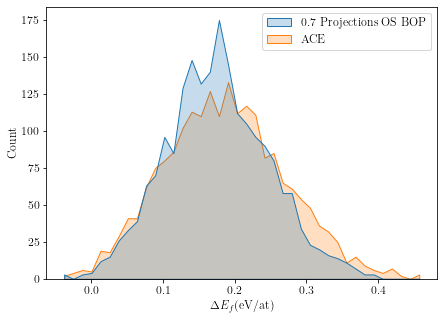

In [58]:
ax = sns.histplot(Prediction_Values_R, element='poly')
ax.set_xlabel(r'$\Delta E_f $(eV/at)')

In [59]:
Prediction_Values_R.keys()

dict_keys(['0.7 Projections OS BOP', 'ACE'])

Text(0, 0.5, '$\\Delta E_f$ (eV/atom)')

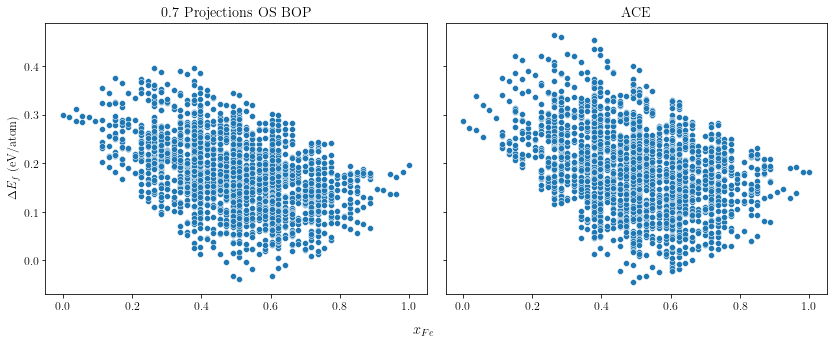

In [60]:
fig, axes = plt.subplots(1, len(Prediction_Values_R), figsize = (plt.rcParams['figure.figsize'][0]*2,plt.rcParams['figure.figsize'][1]), sharey=True)
for ax, (featurename, prediction_values_r) in zip(axes, Prediction_Values_R.items()):
    sns.scatterplot(x = RBS['Fe_pv'], y = prediction_values_r, ax = ax)
    ax.set_title(featurename)
    ax.set_xlabel('')
fig.subplots_adjust(wspace=0.05)
fig.supxlabel(r'$x_{Fe}$')
axes[0].set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [61]:
for featurename, prediction_values  in Prediction_Values_R.items():
    prediction_values.to_pickle(os.path.join(dataset, 'results', f'R_structures_Predicted_{ModelName}_{featurename}_EF_nmhcp.pkl'))

Text(0, 0.5, 'BOP prediction $\\Delta E_f$')

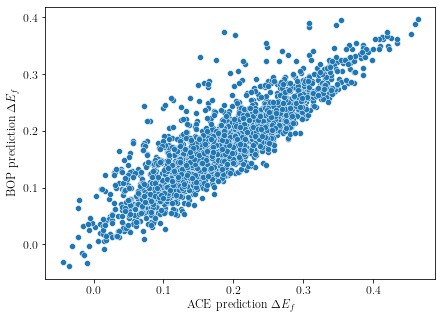

In [62]:
ax = sns.scatterplot(x=Prediction_Values_R['ACE'], y = Prediction_Values_R['0.7 Projections OS BOP'])
ax.set_xlabel(r'ACE prediction $\Delta E_f$')
ax.set_ylabel(r'BOP prediction $\Delta E_f$')

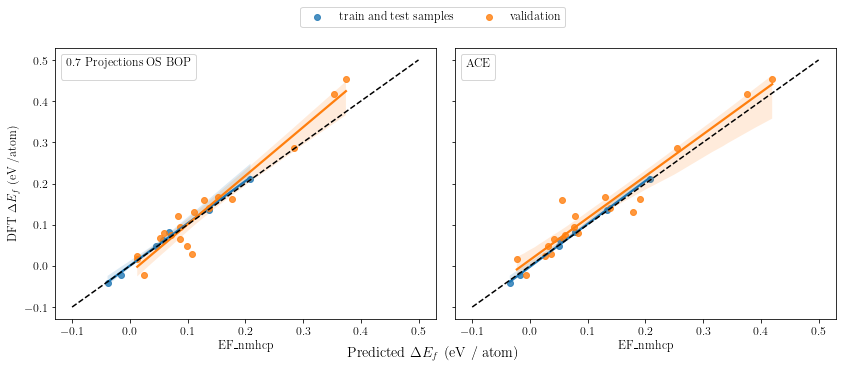

In [63]:
fig, axes = plt.subplots(1, len(Prediction_Values_R), figsize = (plt.rcParams['figure.figsize'][0]*2,plt.rcParams['figure.figsize'][1]), sharey=True)
for ax, (featurename, prediction_values) in zip(axes, Prediction_Values_R.items()):
    prediction_and_train_index = Prediction_Values_R[featurename].index.intersection(TRAIN_RBS.index)
    prediction_and_validation_index = VALIDATION_RBS.index.intersection(Prediction_Values_R[featurename].index)
    sns.regplot(x=Prediction_Values_R[featurename].loc[prediction_and_train_index], y=BS['EF_nmhcp'][prediction_and_train_index], label='train and test samples', ax = ax)
    sns.regplot(x=Prediction_Values_R[featurename].loc[prediction_and_validation_index], y=VALIDATION_RBS[target_case][prediction_and_validation_index], label='validation', ax=ax)
    ax.set_ylabel('')
    ax.plot([-0.1, 0.5], [-0.1, 0.5], '--k')
    ax.legend([],[], title=featurename)
#y2 = axes[0].twinx()
#axes[0].tick_params(axis='y2', direction='in')
axes[0].set_ylabel(r'DFT $\Delta E_f$ (eV /atom)')
fig.supxlabel(r'Predicted $\Delta E_f$ (eV / atom)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol = len(labels), loc = 'upper center', bbox_to_anchor = (0.5, 1.01))
fig.subplots_adjust(wspace=0.05)
fig_filename = os.path.join(dataset, 'graphs', f'{dataset}_prediction_lines_R_train_and_validation.pdf')
fig.savefig(fig_filename)

# Recover learning prediction 

In [64]:
ModelName = 'Kernel Ridge'

In [65]:
#orig_bs = pd.read_pickle('Fe-Mo/ParsedBriefsummary.pkl')

In [66]:
OrigPhaseBS =  {
    '': {'TRAIN R':  TRAIN_RBS}
}

In [67]:
ValidationPhaseBS = {
    '': {'VALIDATION R': VALIDATION_RBS}
}

# New Convex Hulls 

In [68]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
P = Plotting()
points = {}
Prediction_RBS = {}

In [69]:
from scipy.spatial import ConvexHull

In [70]:
from matplotlib.lines import Line2D

In [71]:
from scipy.spatial import QhullError
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    fig_= None,
    ax_ = None,
    components = ['Fe_pv', 'Mo_sv'], 
    palettename = 'tab20c'
):
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        if len(plot_only) == 0:
            plot_only = PhaseBS.keys()
        points = P.get_x_ef_points(PhaseBS, components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if ax_ is None:
            fig_,  ax_ = plt.subplots()#figsize=(12,10)
            handles = []
            labels = []
        else:
            handles, labels = ax_.get_legend_handles_labels()
#        fig = figs_mag[mag]
#        ax = ax_mag[mag]
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                l = ax_.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 1, markersize=2, markeredgecolor='k')
            if plot_points:
                l = ax_.plot(points[phase][components[0]] , points[phase][theproperty], 'o', color = palette[phase], markersize=2)
            handles.append(l[0])
            labels.append(phase)
        leg = ax_.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax_.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax_.set_xlabel(rf'$x_{{{components[0]}}}$')
        fig_.tight_layout()
    return fig_, ax_

In [72]:
stds = {}
errs = {}
good_vertices = {}

In [73]:
palette1 = PlottingChulls.make_palette_forlist(['R'])
palette2 = PlottingChulls.make_palette_forlist(['R'], palette_name='gray')
palette3 = PlottingChulls.make_palette_forlist(['R'], palette_name='hls')

In [74]:
L1 = Line2D([0],[0], marker = 'o', color=palette1['R'], markersize = 1, linewidth = 2)
L2 = Line2D([0],[0], marker = 'o', color=palette2['R'], markersize = 1, linewidth = 2 )
L3 = Line2D([0],[0], marker = 'o', color=palette3['R'], markersize = 1, linewidth = 2 )

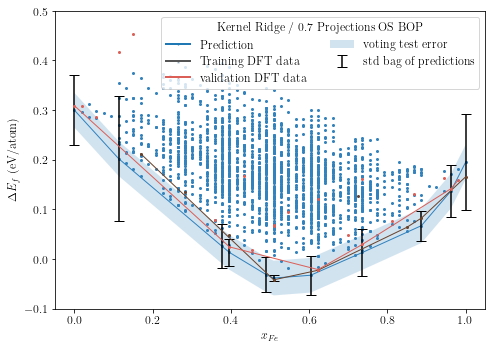

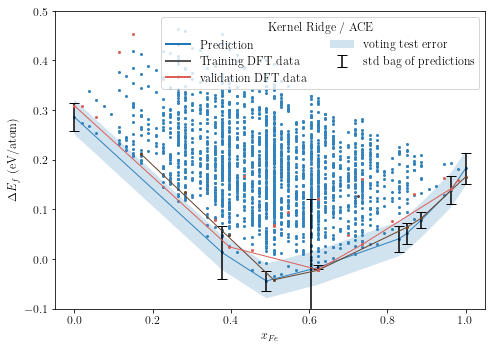

In [75]:
for key, featurename in featurenames.items():
    Prediction_RBS[key] = pd.concat([RBS, Prediction_Values_R[key]], axis = 1)
    points[key] = Prediction_RBS[key][['Fe_pv', target_case]]
    PhasesBS = {'': {'R' : Prediction_RBS[key]}}
    chulls= P.get_convex_hulls(PhasesBS[''], components=['Fe_pv', 'Mo_sv'],
                               viewpoint=[0.5, -10], getproperty=target_case)
    good_vertices[key] = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())
    stds[key] = bag_of_predictions[('Kernel Ridge', key)] .iloc[good_vertices[key]].std(axis=1)
    errs[key] = pd.concat([stds[key], PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds[key].index]], axis = 1 )
    errs[key].rename(columns={0: 'std'}, inplace=True)
    errs[key].sort_values(by='Fe_pv', inplace=True)
    tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=True, fig_ = None, ax_=None)
    e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds[key].index],PhasesBS['']['R'][target_case][stds[key].index],
                 yerr=stds[key], capsize=5, fmt='none', c='k')
    a = tax.fill_between(errs[key]['Fe_pv'], errs[key]['EF_nmhcp']+0.035, errs[key][target_case]-0.035, alpha = 0.2, label='voting test error')
    tfig, tax = plot_chull(OrigPhaseBS,
               target_case,
               mag_list=[''], 
               plot_points=True,
               fig_=tfig,
               ax_=tax, palettename='copper')
    tfig, tax = plot_chull(ValidationPhaseBS,
               target_case,
               mag_list=[''], 
               plot_points=True,
               fig_=tfig,
               ax_=tax,
                           palettename='hls'
                        )
    tax.set_xlabel(r'$x_{Fe}$')
    tax.legend(
        [L1, L2, L3, a, e],
        ['Prediction', 'Training DFT data', 'validation DFT data', 'voting test error', 'std bag of predictions'],
        ncol = 2,
        loc = 'upper right',
        title = f'{ModelName} / {key} '
    )
    tax.set_ylim([-0.1, 0.5])
    file_name = os.path.join(f'Fe-Mo/graphs/R_structure_pred_vs_dft_{ModelName}_{featurename}.pdf')
    tfig.tight_layout()
    tfig.savefig(file_name)

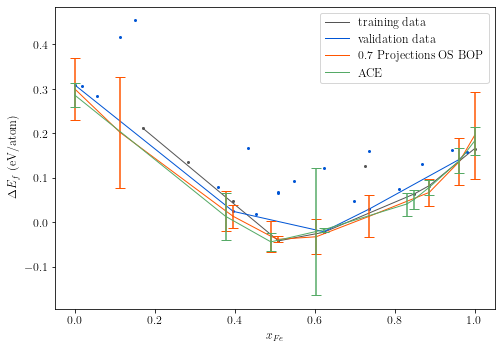

In [76]:
tfig, tax = plot_chull(OrigPhaseBS,
           target_case,
           mag_list=[''], 
           plot_points=True,
           fig_=None,
           ax_=None, palettename='gray')

tfig, tax = plot_chull(ValidationPhaseBS,
           target_case,
           mag_list=[''], 
           plot_points=True,
           fig_=tfig,
           ax_=tax,
                       palettename='winter'
                    )
palettes = {'ACE': 'summer', '0.7 Projections OS BOP': 'autumn'}
lines = tax.get_lines()
handles = [lines[0], lines[-2]]
labels = ['training data', 'validation data']
#plt.legend(['training data', 'validation data'])

for key, featurename in featurenames.items():
    Prediction_RBS[key] = pd.concat([RBS, Prediction_Values_R[key]], axis = 1)
    points[key] = Prediction_RBS[key][['Fe_pv', target_case]]
    PhasesBS = {'': {'R' : Prediction_RBS[key]}}
    chulls= P.get_convex_hulls(PhasesBS[''], components=['Fe_pv', 'Mo_sv'],
                               viewpoint=[0.5, -10], getproperty=target_case)
    good_vertices[key] = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())
    stds[key] = bag_of_predictions[('Kernel Ridge', key)] .iloc[good_vertices[key]].std(axis=1)
    errs[key] = pd.concat([stds[key], PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds[key].index]], axis = 1 )
    errs[key].rename(columns={0: 'std'}, inplace=True)
    errs[key].sort_values(by='Fe_pv', inplace=True)
    tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=False, fig_ =tfig, ax_=tax, palettename = palettes[key] )
    handles.append(tax.get_lines()[-2])
    labels.append(key)
    this_color = tax.get_lines()[-1].get_color()
    e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds[key].index],PhasesBS['']['R'][target_case][stds[key].index],
                 yerr=stds[key], capsize=5, fmt='none', c=this_color)
tax.set_xlabel(r'$x_{Fe}$')
tax.legend(handles, labels)

# Comparision for the other phases 

In [77]:
def get_bs_byphase(theBS):
    verts = {}
    chulls = {}
    phasepoints = {}
    return {mag: {phase: theBS[(theBS.Phase == phase) & theBS.index.str.contains(mag)] for phase in theBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [78]:
OrigPhaseBS = get_bs_byphase(BS)

In [79]:
predictedBS = pd.read_pickle('Fe-Mo/results/Fe-Mo_Kernel Ridge_PredictedBS.pkl')

In [80]:
predictedBS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'EF_nmhcp', 'EF_nmfcc', 'EF_fmbcc', 'Phase',
       'EF_nmhcp_0.6 Projections OS BOP', 'EF_nmhcp_0.7 Projections OS BOP',
       'EF_nmhcp_0.7 Projections OS BOP no CNAV', 'EF_nmhcp_ACE no CNAV',
       'EF_nmhcp_Canonical BOP', 'EF_nmhcp_Canonical BOP no CNAV',
       'EF_nmhcp_Projections OS BOP', 'EF_nmhcp_SOAP_canonicalFe',
       'EF_nmhcp_SOAP_specific', 'EF_nmhcp_SOAP_specific no CNAV',
       'EF_nmhcp_atomic', 'EF_nmhcp_atomic no CNAV', 'EF_nmhcp_dataset',
       'EF_nmhcp_dataset no CNAV', 'EF_nmhcp_ACE', 'EF_nmhcp_Canonical ACE',
       'EF_nmhcp_Canonical ACE no CNAV', 'EF_nmhcp_NOZERO-ACE',
       'EF_nmhcp_NOZERO_NOONE-ACE', 'EF_nmhcp_NOZERO_NOONE_NOTWO-ACE',
       'EF_nmhcp_NOTHREE-ACE', 'EF_nmhcp_NOTHREE-NOTWO_NOONE-ACE',
       'EF_nmhcp_NOZERO-ACE no CNAV', 'EF_nmhcp_NOZERO_NOONE-ACE no 

In [81]:
predictedPhaseBS = get_bs_byphase(predictedBS)

In [82]:
plot_only = ['bcc', 'C14', 'sigma', 'mu', 'C36', 'A15', 'hcp']

In [83]:
palettename = 'Dark2'

In [84]:
ModelName

'Kernel Ridge'

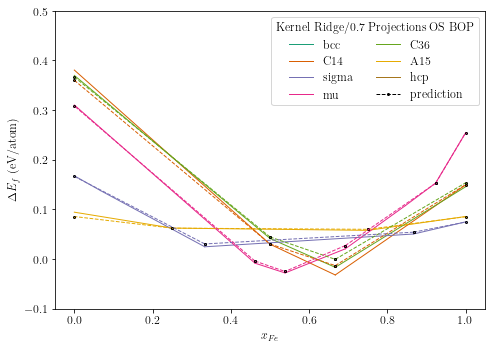

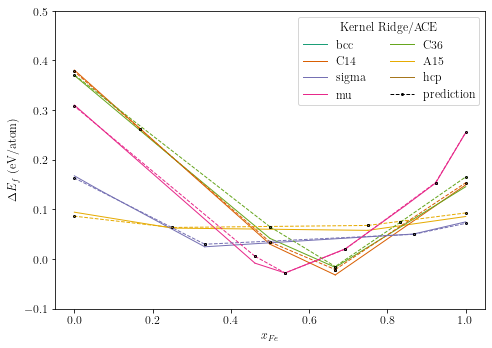

In [86]:
for featurename in featurenames:
    fig, ax = plot_chull(
        predictedPhaseBS, theproperty='EF_nmhcp', mag_list=[''], 
               components= [ 'Fe_pv', 'Mo'], plot_points = False,
        plot_only=plot_only, palettename=palettename
    )

    fig, ax = plot_chull(
        predictedPhaseBS, theproperty=f'EF_nmhcp_{featurename}', mag_list=[''], 
               components= [ 'Fe_pv', 'Mo'], plot_points = False,
        plot_only=plot_only, palettename=palettename, line_styles = '--o', fig_ = fig, ax_ = ax
    )

    ax.set_ylim([-0.1, 0.5])
    palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
    L = []
    label = []
    for name, color in palette.items():
        L.append(Line2D([0], [0], color = color, lw = 1))
        label.append(name)
    L.append(Line2D([0, 1],[0, 0], linestyle = '--', marker = 'o', color='k', linewidth=1, markersize=2))
    label.append('prediction')
    leg = ax.legend(L, label, loc = 'upper right', ncol =2, scatterpoints=2,  title=f'{ModelName}/{featurename}')
    ax.set_xlabel(r'$x_{Fe}$')
    modelforfile=ModelName.replace(' ', '')
    featureforfile=featurename.replace(' ', '')
    fig.tight_layout()
    file_name =os.path.join(dataset, 'graphs', f'{dataset}_CompareCHull_{modelforfile}_{featureforfile}.pdf')
    fig.savefig(file_name)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


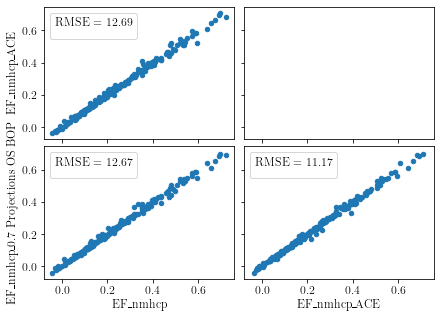

In [89]:
fig, axes = plt.subplots(2,2, sharex = True, sharey = True)
predictedBS.plot.scatter(x='EF_nmhcp_ACE', y= 'EF_nmhcp_0.7 Projections OS BOP', ax = axes[1,1])
rmse = np.sqrt(((predictedBS['EF_nmhcp_ACE'] - predictedBS['EF_nmhcp_0.7 Projections OS BOP'])**2).sum()/len(predictedBS))
axes[1,1].legend(title=f'RMSE = {rmse*1000:5.2f}')
predictedBS.plot.scatter(x='EF_nmhcp', y='EF_nmhcp_0.7 Projections OS BOP' , ax = axes[1,0])
rmse = np.sqrt(((predictedBS['EF_nmhcp'] - predictedBS['EF_nmhcp_0.7 Projections OS BOP'])**2).sum()/len(predictedBS))
axes[1,0].legend(title=f'RMSE = {rmse*1000:5.2f}')
predictedBS.plot.scatter(x='EF_nmhcp', y='EF_nmhcp_ACE' , ax = axes[0,0])
rmse = np.sqrt(((predictedBS['EF_nmhcp'] - predictedBS['EF_nmhcp_ACE'])**2).sum()/len(predictedBS))
fig.subplots_adjust(wspace = 0.05, hspace=0.05)
axes[0,0].legend(title=f'RMSE = {rmse*1000:5.2f}')

In [91]:
predictedBS[['EF_nmhcp']]

,EF_nmhcp
Fe_pv8.A15.FM,0.085535
Fe_pv12.C14.FM,0.149303
Fe_pv24Mo_sv5.chi-BBAA.FM,0.058514
Fe_pv25Mo_sv4.chi-ABAA.FM,0.063911
Fe_pv24.C36.FM,0.145580
...,...
Fe_pv24Mo_sv5.chi-BBAA.NM,0.052194
Fe_pv4Mo_sv2.C15-A2B.NM,0.009861
Fe_pv25Mo_sv4.chi-ABAA.NM,0.057857
Fe_pv16Mo_sv8.C36-BBAAA.NM,-0.016932


#figsize CH  for DFT calculations full

In [92]:
plot_only = plot_only + ['R']

In [93]:
palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)

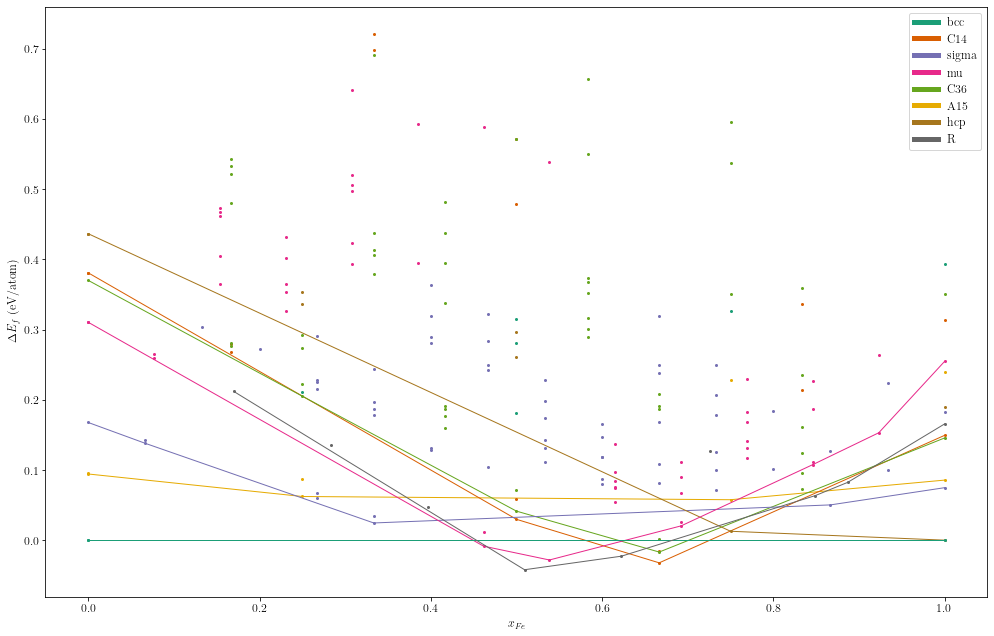

In [94]:
fig, ax = plt.subplots(figsize=(14,9))
fig, ax = plot_chull(
    OrigPhaseBS, theproperty='EF_nmhcp', mag_list=[''], palettename='Dark2', 
    plot_only=plot_only, fig_=fig, ax_ = ax
)
lines = []
labels = []
for name, color in palette.items():
    lines.append(Line2D([0],[0],linewidth = 5, color=color))
    labels.append(name)
ax.legend(lines, labels)
ax.set_xlabel(r'$x_{Fe}$')
filename = os.path.join(dataset, 'graphs', f'{dataset}_ConvexHulls.pdf')
fig.savefig(filename)

In [95]:
OrigPhaseBS['']['C36']

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109714,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,24,0,24,1.000000,0.000000,0.145580,0.145580,0.145580,C36
Fe_pv14Mo_sv10.C36-BAAAB.FM,bulk C36-BAAAB.FM,13.675362 A,-9.070367,167.196222 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.019,0,2,...,Mo_sv,14,10,24,0.583333,0.416667,0.301159,0.301159,0.301159,C36
Fe_pv18Mo_sv6.C36-AAAAB.FM,bulk C36-AAAAB.FM,13.750142 A,-8.574181,167.799984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,18,6,24,0.750000,0.250000,0.350852,0.350852,0.350852,C36
Fe_pv20Mo_sv4.C36-ABAAA.FM,bulk C36-ABAAA.FM,11.993054 A,-8.629109,168.873004 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,20,4,24,0.833333,0.166667,0.072678,0.072678,0.072678,C36
Fe_pv20Mo_sv4.C36-BAAAA.FM,bulk C36-BAAAA.FM,12.004255 A,-8.605800,172.092274 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,20,4,24,0.833333,0.166667,0.095987,0.095987,0.095987,C36
Fe_pv20Mo_sv4.C36-AABAA.FM,bulk C36-AABAA.FM,12.637125 A,-8.467251,172.331196 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,20,4,24,0.833333,0.166667,0.234536,0.234536,0.234536,C36
Fe_pv14Mo_sv10.C36-ABABA.FM,bulk C36-ABABA.FM,13.626146 A,-9.081592,181.866879 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,14,10,24,0.583333,0.416667,0.289934,0.289934,0.289934,C36
Fe_pv10Mo_sv14.C36-BBABA.FM,bulk C36-BBABA.FM,13.807673 A,-9.631021,186.981572 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,10,14,24,0.416667,0.583333,0.186998,0.186998,0.186998,C36
Fe_pv8Mo_sv16.C36-BAABB.FM,bulk C36-BAABB.FM,15.041440 A,-9.662835,200.131249 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,16,24,0.333333,0.666667,0.378430,0.378430,0.378430,C36
Fe_pv6Mo_sv18.C36-BBBAB.FM,bulk C36-BBBAB.FM,14.876555 A,-9.972888,203.866518 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,18,24,0.250000,0.750000,0.291624,0.291624,0.291624,C36


# Bopxplots 

In [96]:
equals = RBS.index.intersection(calcs_R.index)

NameError: name 'calcs_R' is not defined

In [97]:
alldata = pd.concat([RBS['Fe_pv'] , bag_of_predictions], axis = 1).loc[equals]

TypeError: cannot concatenate object of type '<class 'dict'>'; only Series and DataFrame objs are valid

In [ ]:
melted = alldata.melt(id_vars='Fe_pv')

In [ ]:
sns.boxplot(data=melted, x= 'Fe_pv', y = 'value')

In [ ]:
alldata = alldata.loc[equals].melt(id_vars=['Fe_pv'])

In [ ]:
sns.scatterplot(alldata

In [ ]:
ax = sns.scatterplot(x = RBS['Fe_pv'][equals], y = Prediction[equals], label = 'Prediction for R')
sns.scatterplot(data = calcs_R, x = 'Fe_pv', y = 'EF_nmhcp', ax = ax, ls='--', err=ERR[equals])
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [ ]:
ax = sns.scatterplot()